# DataSource (balance border)

The source represents the balance boundary for incoming flows.

<img src = "./model.svg" width=100px>

## Model equations

There are no model equations for the constant source. All variables of the output port are copied to the connected model by the waveform algorithm.


## Parameters

There are no parameters for the model.

## Implementation of the source model with interpolated values (DataSource)


In [6]:
from simunetcore import Model
import numpy as np
import pandas as pd

# Model implementation for the data driven source
# The output vector is interpolated on the basis of the given samples
class DataSource(Model):
    def __init__(self, name=""):
        Model.__init__(self, name)
        
        #  Model parameters
        self.params = {
            "samples": {
                "value": {"t": []}, 
                "description": "Sample points", 
                "unit": "-",
                "property": {
                    "editor": "table",
                    "options": None
                }
            }
        }

    def compute(self, *args, **kwargs):
        # Get the value of the samples parameter
        samples = self.get_param("samples")
        header = samples[0]
        values = samples[1]
        df = pd.DataFrame(values, columns=header)
        # Get the time frame of the samples
        t_sample = df["t"]
        # Handle the vars of the source
        for var_id in self.vars:
            if var_id in df.columns:
                # Get the data for the var from the samples
                y_sample = df[var_id]
                # Interpolate the result
                y = np.interp(self.get_t(), t_sample, y_sample)
            else:
                len_t = len(self.get_t())
                initial_y = self.get_var(var_id)[-1]
                y = np.full(len_t, initial_y) 
            # Set results
            self.set_var(var_id, y)


## Computation of the source model with interpolated values (DataSource)

In [7]:
# Create model
In_2 = DataSource("In_1")

# Setup vars and output port
In_2.vars = {
    "A" : {"description": "Var A", "unit": ""},
    "B" : {"description": "Var B", "unit": ""},
    "C" : {"description": "Var C", "unit": ""},
    "D" : {"description": "Var D", "unit": "", "value":[255.0]}
}
In_2.y["y_1"] = {
    "type": "source", 
    "description": "source", 
    "vars": ["A", "B", "C", "D"]
}

# Setup integration time
t_start = 0.0
t_end = 300.0
numpoints = 101
In_2.set_t(np.linspace(t_start, t_end, numpoints))

# Create some samples
sample_count = 21
t_sample = np.linspace(t_start, t_end, sample_count)
A_sample = np.linspace(55.0, 870.0, sample_count)
B_sample = np.sin(t_sample*0.5)*100.0 + 310.0
C_sample = np.piecewise(
    t_sample, 
    [t_sample < 100, t_sample >= 100, t_sample >= 200], 
    [390.0, 520.0, 58.0])

samples = [["t", "A", "B", "C"], list(zip(t_sample, A_sample, B_sample, C_sample))]
In_2.set_param("samples", samples)

# Test the compute method
In_2.compute()

## Results

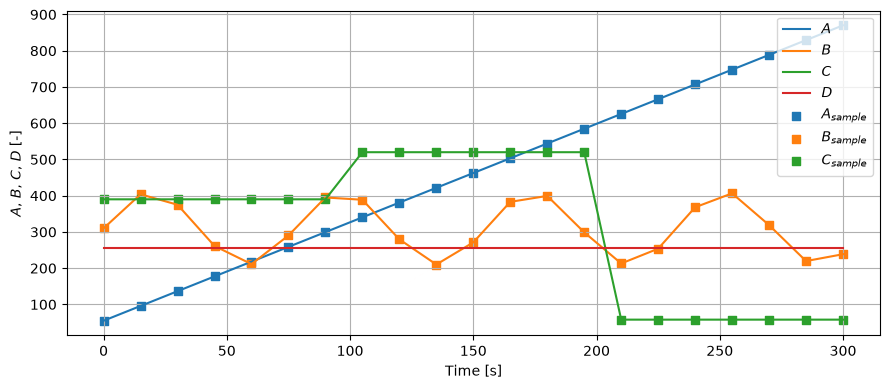

In [8]:
import matplotlib
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(9,4))

# Plot values
plt.plot(In_2.get_t(), In_2.get_var("A", In_2.get_t()), label="$A$")
plt.plot(In_2.get_t(), In_2.get_var("B", In_2.get_t()), label="$B$")
plt.plot(In_2.get_t(), In_2.get_var("C", In_2.get_t()), label="$C$")
plt.plot(In_2.get_t(), In_2.get_var("D", In_2.get_t()), label="$D$")

plt.scatter(t_sample, A_sample, color="C0", marker="s", label="$A_{sample}$")
plt.scatter(t_sample, B_sample, color="C1", marker="s", label="$B_{sample}$")
plt.scatter(t_sample, C_sample, color="C2", marker="s", label="$C_{sample}$")

# Axis labels
plt.ylabel("$A$, $B$, $C$, $D$ [-]")
plt.xlabel('Time [s]')

# Show grid
plt.grid(True)

# Show legend
plt.legend(loc=1)   

# Layout and show
plt.tight_layout()
plt.show()